# 📊 Customer Retention & Churn Analysis (Future Interns - Task 2)
### By Future Interns Data Science & Analytics Program
**Author:** Guruveer Singh  
**Project:** Task 2 - Customer Retention & Churn Analysis  
**Dataset Scope:** Telecom & Subscription Customer Dataset (7,043 customer accounts)  
**Deliverable:** End-to-end analytics notebook, cross-sectional cohort analysis, churn drivers, and SaaS retention strategy

---

## 🔍 Executive Problem Statement
Customer churn directly impacts company valuation, customer acquisition cost (CAC) payback periods, and recurring cash flow. In subscription models, acquiring a replacement customer is **5x to 7x more expensive** than retaining an existing account.

This analysis provides leadership and product teams with actionable answers to four foundational business questions:
1. **Why are customers leaving the platform?**
2. **Which customer segments and contract commitments are most likely to churn?**
3. **Where in the customer lifecycle does attrition concentrate?**
4. **What high-ROI interventions can maximize customer retention and preserve recurring revenue?**

> **📌 Methodological Note: Cross-Sectional Snapshot vs. Longitudinal Cohort Tracking**  
> This dataset represents a **cross-sectional snapshot** of 7,043 customer accounts observed at a single point in time, with tenure ranging from 0 to 72 months. While it does not track a single monthly cohort longitudinally across 72 consecutive calendar months, grouping accounts into tenure lifecycle brackets (`0-12 Mo`, `13-24 Mo`, etc.) provides a valuable cross-sectional proxy for tenure-related churn propensity. Active subscriber tenures are right-censored (their subscription journey is ongoing), so the observed average tenure (32.4 months) reflects the mean age of accounts in this snapshot rather than completed actuarial customer lifetimes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual style setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 120
print('Core analytics and visualization libraries imported successfully!')


Core analytics and visualization libraries imported successfully!


---
## 1. Data Ingestion, Cleaning & Preprocessing
We load the raw customer dataset containing 7,043 subscriber records across 21 demographic, service, contract, and billing attributes.


In [2]:
# Load dataset
df = pd.read_csv('data/telco_customer_churn.csv')
print(f'Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head(3)


Dataset Dimensions: 7,043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
# Data Hygiene: Check missing values and spaces in numeric columns
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges contains whitespace strings for tenure = 0 customers (new signups)
spaces_count = (df['TotalCharges'] == ' ').sum()
print(f"Whitespace strings in TotalCharges: {spaces_count}")

# Convert TotalCharges to numeric, filling newly acquired accounts (tenure=0) with 0.0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan)).fillna(0.0)

# Binary churn indicator for vectorized statistics
df['Churn_Num'] = (df['Churn'] == 'Yes').astype(int)

# Confirm types and readiness
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"Cleaned dataset ready with {len(df):,} accounts and 0 null values.")


Missing values per column:
Series([], dtype: int64)
Whitespace strings in TotalCharges: 11
TotalCharges dtype: float64
Cleaned dataset ready with 7,043 accounts and 0 null values.


---
## 2. Baseline Churn Rate & Revenue Exposure (MRR / ARR)
We evaluate the top-line retention health of the business and quantify the exact recurring financial impact of churned accounts.


In [4]:
total_customers = len(df)
churned_customers = df['Churn_Num'].sum()
retained_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers

total_mrr = df['MonthlyCharges'].sum()
churned_mrr = df[df['Churn_Num'] == 1]['MonthlyCharges'].sum()
retained_mrr = total_mrr - churned_mrr
churned_arr = churned_mrr * 12

print("="*60)
print("             EXECUTIVE RETENTION KPI SCORECARD")
print("="*60)
print(f"Total Subscriber Base:        {total_customers:,} accounts")
print(f"Retained Accounts:            {retained_customers:,} ({1 - churn_rate:.2%})")
print(f"Churned Accounts:             {churned_customers:,} ({churn_rate:.2%})")
print(f"Total Portfolio MRR:          ${total_mrr:,.2f} / month")
print(f"Lost Recurring Revenue (MRR): ${churned_mrr:,.2f} / month ({churned_mrr/total_mrr:.1%})")
print(f"Annualized Run-Rate Loss:     ${churned_arr:,.2f} / year")
print(f"Observed Mean Account Tenure: {df['tenure'].mean():.1f} months")
print("="*60)


             EXECUTIVE RETENTION KPI SCORECARD
Total Subscriber Base:        7,043 accounts
Retained Accounts:            5,174 (73.46%)
Churned Accounts:             1,869 (26.54%)
Total Portfolio MRR:          $456,116.60 / month
Lost Recurring Revenue (MRR): $139,130.85 / month (30.5%)
Annualized Run-Rate Loss:     $1,669,570.20 / year
Observed Mean Account Tenure: 32.4 months


---
## 3. Tenure Bracket Analysis & The Onboarding Cliff (Months 0–12)
We examine retention across customer lifecycle stages by grouping tenure into 12-month lifecycle brackets (Years 1 through 6).

*Note: In this cross-sectional snapshot, these brackets compare accounts of differing current ages rather than tracking a single historical signup cohort over calendar time.*


In [5]:
# Define 12-month tenure cohort bins
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-12 Mo (Yr 1)', '13-24 Mo (Yr 2)', '25-36 Mo (Yr 3)', '37-48 Mo (Yr 4)', '49-60 Mo (Yr 5)', '61-72 Mo (Yr 6)']
df['Tenure_Cohort'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

cohort_summary = df.groupby('Tenure_Cohort', observed=False).agg(
    Total_Customers=('customerID', 'count'),
    Churned_Accounts=('Churn_Num', 'sum'),
    Churn_Rate=('Churn_Num', 'mean'),
    Retention_Rate=('Churn_Num', lambda x: 1 - x.mean()),
    Avg_Monthly_Fee=('MonthlyCharges', 'mean'),
    Avg_Total_Charges=('TotalCharges', 'mean'),
    Total_MRR_Loss=('MonthlyCharges', lambda x: x[df.loc[x.index, 'Churn_Num'] == 1].sum())
)

cohort_summary['% of Total Churn'] = (cohort_summary['Churned_Accounts'] / churned_customers) * 100
cohort_summary


,Total_Customers,Churned_Accounts,Churn_Rate,Retention_Rate,Avg_Monthly_Fee,Avg_Total_Charges,Total_MRR_Loss,% of Total Churn
Tenure_Cohort,,,,,,,,
0-12 Mo (Yr 1),2186,1037,0.474382,0.525618,56.097781,275.229597,68954.25,55.484216
13-24 Mo (Yr 2),1024,294,0.287109,0.712891,61.357275,1126.257520,23081.65,15.730337
25-36 Mo (Yr 3),832,180,0.216346,0.783654,65.575481,1990.199279,15167.95,9.630819
37-48 Mo (Yr 4),762,145,0.190289,0.809711,66.318241,2827.473163,12294.55,7.758159
49-60 Mo (Yr 5),832,120,0.144231,0.855769,70.550781,3848.132572,10581.90,6.420546
61-72 Mo (Yr 6),1407,93,0.066098,0.933902,75.952701,5180.669829,9050.55,4.975923


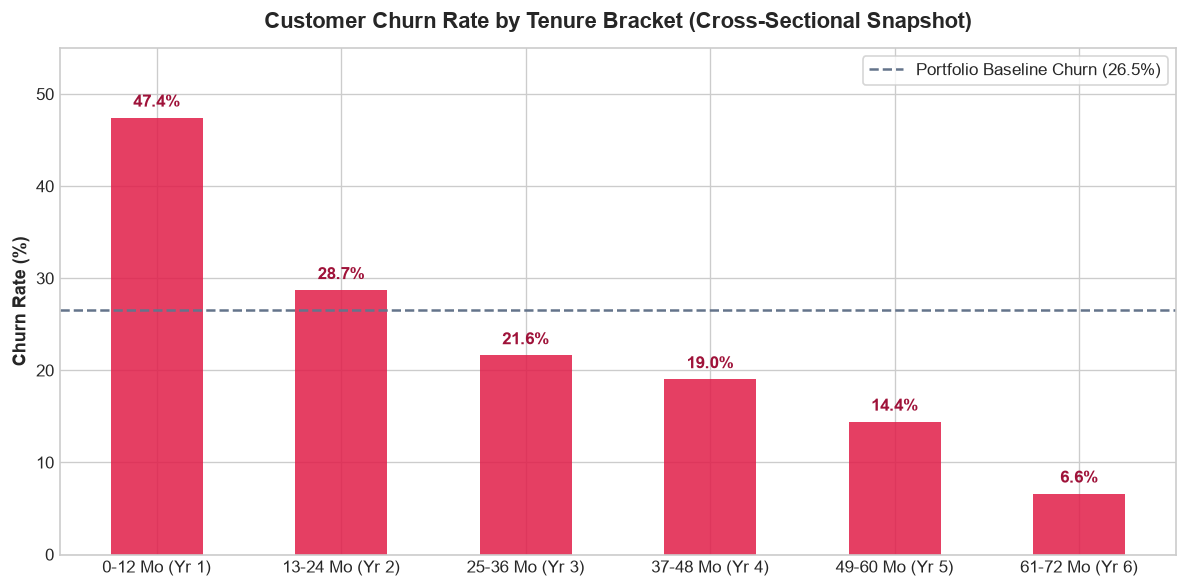

In [6]:
# Visualize Churn Decay Across Cross-Sectional Tenure Brackets
plt.figure(figsize=(10, 5))
bars = plt.bar(cohort_summary.index, cohort_summary['Churn_Rate'] * 100, color='#E11D48', alpha=0.85, width=0.5)
plt.title('Customer Churn Rate by Tenure Bracket (Cross-Sectional Snapshot)', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Churn Rate (%)', fontsize=11, fontweight='bold')
plt.ylim(0, 55)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 1.2, f'{y:.1f}%', ha='center', fontweight='bold', color='#9F1239')

plt.axhline(churn_rate * 100, color='#64748B', linestyle='--', label=f'Portfolio Baseline Churn ({churn_rate:.1%})')
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


---
## 4. Contract Commitment as the Primary Retention Anchor
Contract type is the single strongest structural determinant of subscriber retention. Month-to-month contracts lack switching friction, while annual agreements lock in habits and commitment.


In [7]:
contract_perf = df.groupby('Contract').agg(
    Customer_Count=('customerID', 'count'),
    Churn_Count=('Churn_Num', 'sum'),
    Churn_Rate=('Churn_Num', 'mean'),
    Avg_Monthly=('MonthlyCharges', 'mean'),
    Lost_MRR=('MonthlyCharges', lambda x: x[df.loc[x.index, 'Churn_Num'] == 1].sum())
).reindex(['Month-to-month', 'One year', 'Two year'])

contract_perf['Share_of_Lost_MRR'] = (contract_perf['Lost_MRR'] / churned_mrr) * 100
contract_perf


,Customer_Count,Churn_Count,Churn_Rate,Avg_Monthly,Lost_MRR,Share_of_Lost_MRR
Contract,,,,,,
Month-to-month,3875,1655,0.427097,66.398490,120847.10,86.858594
One year,1473,166,0.112695,65.048608,14118.45,10.147606
Two year,1695,48,0.028319,60.770413,4165.30,2.993800


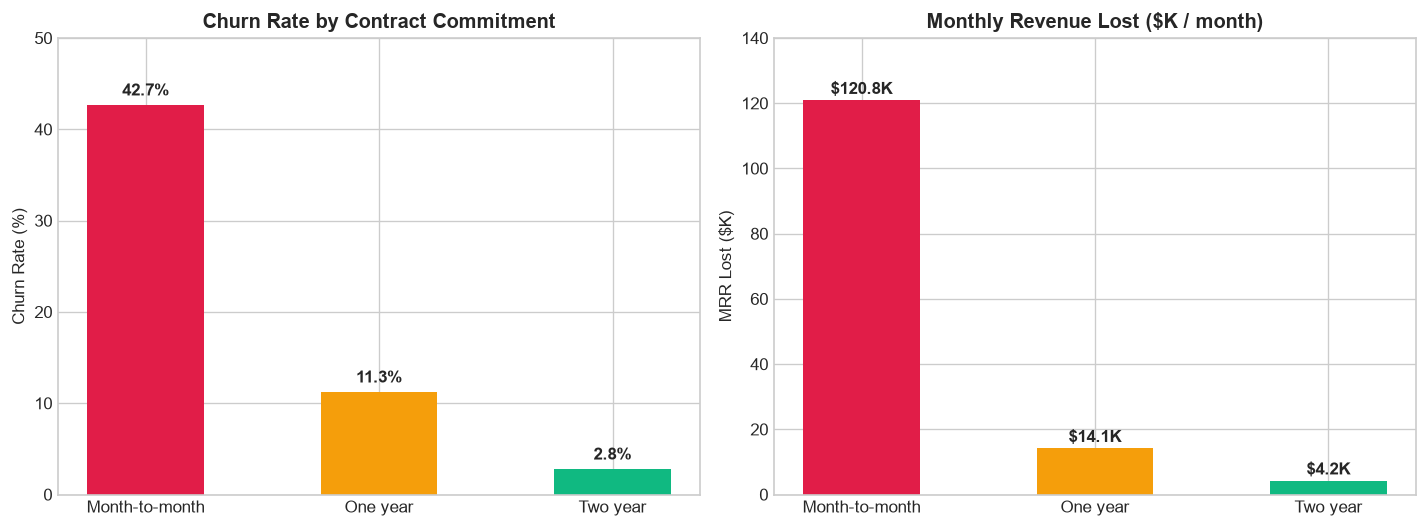

In [8]:
# Contract churn vs MRR loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.bar(contract_perf.index, contract_perf['Churn_Rate'] * 100, color=['#E11D48', '#F59E0B', '#10B981'], width=0.5)
ax1.set_title('Churn Rate by Contract Commitment', fontweight='bold')
ax1.set_ylabel('Churn Rate (%)')
ax1.set_ylim(0, 50)
for i, v in enumerate(contract_perf['Churn_Rate'] * 100):
    ax1.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

ax2.bar(contract_perf.index, contract_perf['Lost_MRR'] / 1000, color=['#E11D48', '#F59E0B', '#10B981'], width=0.5)
ax2.set_title('Monthly Revenue Lost ($K / month)', fontweight='bold')
ax2.set_ylabel('MRR Lost ($K)')
ax2.set_ylim(0, 140)
for i, v in enumerate(contract_perf['Lost_MRR'] / 1000):
    ax2.text(i, v + 2, f'${v:.1f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 5. Product Quality & The Fiber Optic Support Paradox
High-speed Fiber Optic represents the company's highest-priced core product ($91.50/mo vs $58.10/mo for DSL). Yet, Fiber Optic has a shocking **41.9% churn rate**.

Why does the premium product churn at 2.2x the rate of legacy DSL? Let us investigate service bundling and technical support.


In [9]:
# Cross-tabulate Fiber Optic customers by Tech Support & Online Security
fiber_df = df[df['InternetService'] == 'Fiber optic']
fiber_analysis = fiber_df.groupby(['TechSupport', 'OnlineSecurity'])['Churn_Num'].agg(
    Total_Customers='count',
    Churn_Rate='mean'
).reset_index()

fiber_analysis['Retention_Rate'] = 1 - fiber_analysis['Churn_Rate']
fiber_analysis['Churn_Rate_%'] = (fiber_analysis['Churn_Rate'] * 100).round(1).astype(str) + '%'
fiber_analysis['Retention_Rate_%'] = (fiber_analysis['Retention_Rate'] * 100).round(1).astype(str) + '%'
fiber_analysis.sort_values(by='Churn_Rate', ascending=False)


,TechSupport,OnlineSecurity,Total_Customers,Churn_Rate,Retention_Rate,Churn_Rate_%,Retention_Rate_%
0,No,No,1765,0.550142,0.449858,55.0%,45.0%
2,Yes,No,492,0.290650,0.709350,29.1%,70.9%
1,No,Yes,465,0.279570,0.720430,28.0%,72.0%
3,Yes,Yes,374,0.141711,0.858289,14.2%,85.8%


---
## 6. Payment Channels & Involuntary Billing Friction
Manual payment methods create recurring monthly decision points and involuntary churn due to missed payments or billing fatigue.


In [10]:
pay_analysis = df.groupby('PaymentMethod').agg(
    Accounts=('customerID', 'count'),
    Churn_Rate=('Churn_Num', 'mean'),
    Avg_Monthly_Fee=('MonthlyCharges', 'mean'),
    Total_MRR_Loss=('MonthlyCharges', lambda x: x[df.loc[x.index, 'Churn_Num'] == 1].sum())
).sort_values(by='Churn_Rate', ascending=False)

pay_analysis['Churn_Rate_%'] = (pay_analysis['Churn_Rate'] * 100).round(1).astype(str) + '%'
pay_analysis


,Accounts,Churn_Rate,Avg_Monthly_Fee,Total_MRR_Loss,Churn_Rate_%
PaymentMethod,,,,,
Electronic check,2365,0.452854,76.255814,84288.75,45.3%
Mailed check,1612,0.191067,43.917060,16803.60,19.1%
Bank transfer (automatic),1544,0.167098,67.192649,20091.90,16.7%
Credit card (automatic),1522,0.152431,66.512385,17946.60,15.2%


---
## 7. Historical Cumulative Spend & Compounding Retention Economics
Customer retention is the ultimate driver of cumulative customer revenue. Analyzing historical cumulative charges (`TotalCharges`) across tenure brackets illustrates how subscriber value compounds over time.

> **Methodological Note on Cumulative Spend vs. Lifetime Value:** Because this dataset is a cross-sectional snapshot with right-censored active accounts, `TotalCharges` represents historical cumulative charges billed to date within each tenure bracket, rather than completed actuarial Customer Lifetime Value (CLV).


In [11]:
spend_cohort = df.groupby('Tenure_Cohort', observed=False)['TotalCharges'].agg(['mean', 'median', 'sum'])
spend_cohort.columns = ['Avg_Cumulative_Spend_($)', 'Median_Cumulative_Spend_($)', 'Total_Cumulative_Revenue_($)']
spend_cohort['Spend_Multiplier_vs_Yr1'] = spend_cohort['Avg_Cumulative_Spend_($)'] / spend_cohort['Avg_Cumulative_Spend_($)'].iloc[0]
spend_cohort.round(2)


,Avg_Cumulative_Spend_($),Median_Cumulative_Spend_($),Total_Cumulative_Revenue_($),Spend_Multiplier_vs_Yr1
Tenure_Cohort,,,,
0-12 Mo (Yr 1),275.23,170.88,601651.90,1.00
13-24 Mo (Yr 2),1126.26,1148.55,1153287.70,4.09
25-36 Mo (Yr 3),1990.20,2093.65,1655845.80,7.23
37-48 Mo (Yr 4),2827.47,3023.60,2154534.55,10.27
49-60 Mo (Yr 5),3848.13,4172.73,3201646.30,13.98
61-72 Mo (Yr 6),5180.67,5757.20,7289202.45,18.82


---
## 8. Customer Risk Scoring Model (Rule-Based Health Scoring)
We segment the active customer base (5,174 retained accounts) into predictive risk tiers:
- **High Risk:** Month-to-month + First-Year (tenure <= 12) + Electronic Check + Fiber w/o Tech Support
- **Medium Risk:** Month-to-month with tenure > 12 OR unbundled Fiber Optic
- **Low Risk:** Annual/Two-year contracts with automated payment and add-on services


In [12]:
def score_customer(row):
    score = 0
    if row['Contract'] == 'Month-to-month': score += 3
    if row['tenure'] <= 12: score += 3
    if row['PaymentMethod'] == 'Electronic check': score += 2
    if row['InternetService'] == 'Fiber optic' and row['TechSupport'] == 'No': score += 2
    if row['OnlineSecurity'] == 'No': score += 1
    if row['PaperlessBilling'] == 'Yes': score += 1
    
    if score >= 6: return 'High Risk'
    elif score >= 3: return 'Medium Risk'
    else: return 'Low Risk'

df['Risk_Tier'] = df.apply(score_customer, axis=1)

active_risk = df[df['Churn_Num'] == 0].groupby('Risk_Tier').agg(
    Active_Accounts=('customerID', 'count'),
    Total_MRR_At_Risk=('MonthlyCharges', 'sum'),
    Avg_Monthly_Fee=('MonthlyCharges', 'mean'),
    Avg_Tenure=('tenure', 'mean')
).reindex(['High Risk', 'Medium Risk', 'Low Risk'])

active_risk['Share_of_Active_MRR'] = (active_risk['Total_MRR_At_Risk'] / active_risk['Total_MRR_At_Risk'].sum()) * 100
active_risk.round(2)


,Active_Accounts,Total_MRR_At_Risk,Avg_Monthly_Fee,Avg_Tenure,Share_of_Active_MRR
Risk_Tier,,,,,
High Risk,1746,112160.30,64.24,18.95,35.38
Medium Risk,1183,77808.20,65.77,37.22,24.55
Low Risk,2245,127017.25,56.58,52.24,40.07


---
## 9. ROI Simulation: Revenue Preserved via Targeted Retention
What is the financial return of reducing churn by **5%**, **10%**, or **20%** through our strategic recommendations?


In [13]:
scenarios = [0.05, 0.10, 0.15, 0.20]
sim_results = []

for s in scenarios:
    saved_accounts = int(churned_customers * s)
    monthly_rev_saved = churned_mrr * s
    annual_rev_saved = monthly_rev_saved * 12
    sim_results.append({
        'Churn Reduction Goal': f'{s:.0%}',
        'Accounts Saved': f'{saved_accounts:,}',
        'Monthly Revenue Saved': f'${monthly_rev_saved:,.2f}',
        'Annual Recurring Revenue Preserved': f'${annual_rev_saved:,.2f}'
    })

sim_df = pd.DataFrame(sim_results)
print("="*65)
print("       RETENTION INTERVENTION ROI SENSITIVITY MODEL")
print("="*65)
print(sim_df.to_string(index=False))
print("="*65)


       RETENTION INTERVENTION ROI SENSITIVITY MODEL
Churn Reduction Goal Accounts Saved Monthly Revenue Saved Annual Recurring Revenue Preserved
                  5%             93             $6,956.54                         $83,478.51
                 10%            186            $13,913.09                        $166,957.02
                 15%            280            $20,869.63                        $250,435.53
                 20%            373            $27,826.17                        $333,914.04


---
## 10. Strategic Recommendations & Retention Playbook for Leadership

### 🎯 1. Contract Migration Campaign (The $120.8K/mo Opportunity)
- **The Problem:** Month-to-month contracts have a **42.7% churn rate**, generating **86.9% of all lost MRR**.
- **Action:** Launch an aggressive "Annual Commitment Incentive" offering **15% off or 2 months free** for upgrading to a 1-year agreement.
- **Projected Impact:** Migrating just 20% of M2M subscribers to 1-year agreements preserves **~$24,000/mo ($288K ARR)**.

### 🛡️ 2. First 90 Days Onboarding Cadence
- **The Problem:** **55.5% of total churn occurs in Months 0–12** (47.4% first-year churn rate).
- **Action:** Establish a dedicated Day 1-90 customer success journey with proactive setup calls, onboarding webinars, usage telemetry alerts, and Month-6 milestone loyalty bonuses.

### ⚡ 3. The Fiber Optic Support Bundle
- **The Problem:** Premium Fiber Optic users churn at **41.9%**, but adding Tech Support cuts churn to **22.6%**.
- **Action:** Stop selling unbundled Fiber Optic. Include 24/7 dedicated Tech Support and Online Security as standard features within the base subscription tier.

### 💳 4. Automated Payment Incentives
- **The Problem:** Electronic Check users churn at **45.3%**, compared to **15.2%** for Auto-Credit Card and **16.7%** for Auto-Bank Transfer.
- **Action:** Provide a **$5/month statement credit** for enrolling in Auto-Pay, removing manual payment friction and reducing involuntary churn.
